# Indicador de Convergência Temporal (ICT) - Pipeline Completa de Ciência de Dados

## Agregador de pesquisas eleitorais com validação, ajuste de viés, pesos de precisão, ICT por instituto, testes estatísticos, visualizações avançadas e exportações

**Objetivo**: Implementar um pipeline robusto de ciência de dados para avaliar a convergência temporal de institutos de pesquisa eleitoral


## SUMÁRIO EXECUTIVO

Este notebook implementa um pipeline completo de ciência de dados para calcular o **Indicador de Convergência Temporal (ICT)**, uma métrica inovadora que avalia a dinâmica de convergência de institutos de pesquisa eleitoral ao longo do tempo.

### Principais Características:
- **Validação robusta** de dados de entrada
- **Agregador ponderado** com ajuste de viés metodológico
- **Cálculo do ICT** baseado em redução de distância ao consenso
- **Testes estatísticos** completos (normalidade, pareados, comparação)
- **Visualizações avançadas** (7 gráficos novos + gráficos originais)
- **Exportações estruturadas** em CSV, Excel e PNG
- **Logging e rastreabilidade** completa da execução

### Estrutura da Pipeline:
1. **Importações e Configuração** - Ambiente e estilos
2. **Localização de Dados** - Detecção automática da base limpa
3. **Validação de Dados** - Verificação de qualidade (NOVO)
4. **Padronização** - Limpeza e preparação
5. **Agregador Provisório** - Primeira agregação
6. **Ajuste de Viés** - Pesos por método e tipo de pergunta
7. **Agregador Final** - Resultado consolidado
8. **Bimestres Dinâmicos** - Criação de períodos
9. **Cálculo do ICT** - Indicador principal
10. **Testes Estatísticos** - Validação inferencial
11. **Visualizações** - Gráficos (7 novos + originais)
12. **Exportações** - Saídas estruturadas
13. **Relatório Final** - Sumário automático


In [10]:
# Instalação de dependências (executar apenas se necessário)
%pip install pandas openpyxl numpy matplotlib seaborn scipy scikit-learn ipython -q


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## 1. Importações e Configuração

Esta seção configura o ambiente, importa bibliotecas necessárias e estabelece estilos visuais consistentes com o padrão de artigo científico.


In [64]:
# ============================================================================
# IMPORTAÇÕES E CONFIGURAÇÃO DE AMBIENTE
# ============================================================================

import hashlib
import logging
import math
import re
import sys
import textwrap
import unicodedata
import warnings
from datetime import datetime
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display
from matplotlib.lines import Line2D
from matplotlib.ticker import PercentFormatter
from scipy import stats

warnings.filterwarnings("ignore")

# ============================================================================
# CONFIGURAÇÃO DE LOGGING
# ============================================================================

OUTPUT_DIR = Path.cwd() / "saida_agregador_ict"
OUTPUT_DIR.mkdir(exist_ok=True)

# Configurar logging
log_file = OUTPUT_DIR / "notebook_execution.log"
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s',
    handlers=[
        logging.FileHandler(log_file),
        logging.StreamHandler()
    ]
)
logger = logging.getLogger(__name__)

logger.info("=" * 80)
logger.info("INICIANDO PIPELINE DE CIÊNCIA DE DADOS - ICT")
logger.info(f"Data/Hora: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
logger.info(f"Python: {sys.version}")
logger.info(f"pandas: {pd.__version__}")
logger.info(f"numpy: {np.__version__}")
logger.info("=" * 80)

# ============================================================================
# PALETAS DE CORES E ESTILOS
# ============================================================================

PALETA_ARTIGO = [
    "#1D3557",  # Azul escuro
    "#457B9D",  # Azul médio
    "#2A9D8F",  # Verde-azulado
    "#E9C46A",  # Amarelo
    "#F4A261",  # Laranja claro
    "#E76F51",  # Laranja escuro
    "#6D597A",  # Roxo
    "#7A8E99",  # Cinza-azulado
]

CLASS_COLOR_MAP = {
    "Convergencia Esperada": "#2A9D8F",      # Verde (convergência)
    "Comportamento Neutro": "#4C78A8",       # Azul (neutro)
    "Divergencia Persistente": "#D1495B",    # Vermelho (divergência)
    "Sem dado final": "#9AA5B1",             # Cinza (sem dado)
    "ICT indefinido": "#9AA5B1",             # Cinza (indefinido)
}

# ============================================================================
# FUNÇÕES DE ESTILO E VISUALIZAÇÃO
# ============================================================================

def configurar_estilo_artigo():
    """Configura estilos visuais consistentes para todos os gráficos."""
    sns.set_theme(style="whitegrid", context="notebook", font="DejaVu Sans")
    plt.rcParams.update({
        "figure.figsize": (13, 7),
        "figure.dpi": 120,
        "savefig.dpi": 320,
        "font.size": 11,
        "axes.titlesize": 15,
        "axes.labelsize": 12,
        "axes.titleweight": "bold",
        "axes.edgecolor": "#D8DEE9",
        "axes.linewidth": 0.9,
        "axes.facecolor": "#FFFFFF",
        "figure.facecolor": "#FFFFFF",
        "grid.color": "#D8DEE9",
        "grid.linewidth": 0.8,
        "legend.frameon": False,
        "legend.fontsize": 10,
        "xtick.color": "#3B4252",
        "ytick.color": "#3B4252",
        "text.color": "#2E3440",
        "axes.labelcolor": "#2E3440",
        "axes.titlecolor": "#1F2933",
    })

def wrap_label(texto, largura=28):
    """Quebra texto longo em múltiplas linhas."""
    texto = "" if pd.isna(texto) else str(texto)
    return textwrap.fill(texto, width=largura, break_long_words=False, break_on_hyphens=False)

def estilizar_eixo(ax, eixo_percentual=None):
    """Aplica estilo padrão aos eixos de um gráfico."""
    sns.despine(ax=ax, top=True, right=True)
    ax.grid(axis="y", color="#D8DEE9", alpha=0.85, linewidth=0.8)
    ax.grid(axis="x", visible=False)
    if eixo_percentual == "y":
        ax.yaxis.set_major_formatter(PercentFormatter(1.0))
    elif eixo_percentual == "x":
        ax.xaxis.set_major_formatter(PercentFormatter(1.0))

# Aplicar estilo
configurar_estilo_artigo()

# ============================================================================
# GERENCIAMENTO DE ARQUIVOS
# ============================================================================

arquivos_gerados = []
graficos_gerados = []

def registrar_arquivo(caminho):
    """Registra um arquivo gerado para rastreamento."""
    caminho = Path(caminho)
    if caminho not in arquivos_gerados:
        arquivos_gerados.append(caminho)
        logger.info(f"Arquivo registrado: {caminho.name}")
    return caminho

def salvar_figura(fig, nome_arquivo):
    """Salva figura em alta resolução."""
    try:
        caminho = OUTPUT_DIR / nome_arquivo
        fig.patch.set_facecolor("white")
        fig.savefig(caminho, dpi=320, bbox_inches="tight", facecolor="white")
        if caminho not in graficos_gerados:
            graficos_gerados.append(caminho)
        registrar_arquivo(caminho)
        print(f"Grafico salvo: {caminho.name}")
        logger.info(f"Gráfico salvo com sucesso: {nome_arquivo}")
        return caminho
    except Exception as e:
        logger.error(f"Erro ao salvar figura {nome_arquivo}: {e}")
        raise

print("✓ Ambiente configurado com sucesso.")
print(f"✓ Diretório de saída: {OUTPUT_DIR}")
print(f"✓ Log de execução: {log_file}")


2026-04-30 17:06:01,779 - INFO - ================================================================================
2026-04-30 17:06:01,782 - INFO - INICIANDO PIPELINE DE CIÊNCIA DE DADOS - ICT
2026-04-30 17:06:01,785 - INFO - Data/Hora: 2026-04-30 17:06:01
2026-04-30 17:06:01,788 - INFO - Python: 3.11.9 (main, May 10 2024, 16:48:02) [GCC 13.2.0]
2026-04-30 17:06:01,791 - INFO - pandas: 3.0.2
2026-04-30 17:06:01,792 - INFO - numpy: 2.4.4
2026-04-30 17:06:01,794 - INFO - ================================================================================


✓ Ambiente configurado com sucesso.
✓ Diretório de saída: /home/jackson/Downloads/CD/saida_agregador_ict
✓ Log de execução: /home/jackson/Downloads/CD/saida_agregador_ict/notebook_execution.log


## 2. Localização Automática da Base Limpa

O notebook detecta automaticamente a base de dados de entrada, verificando primeiro em memória e depois no sistema de arquivos.


In [65]:
# ============================================================================
# LOCALIZAÇÃO AUTOMÁTICA DA BASE LIMPA
# ============================================================================

logger.info("Iniciando localização da base limpa...")

# Caminhos preferenciais (Windows)
caminhos_preferenciais = [
    Path.cwd() / "base_limpa_Presidente2_UDESC.xlsx"
    # Path.cwd() / "base_limpa.xlsx",
    # Path.cwd() / "base_limpa.csv",
]

base_limpa = None
fonte_base_limpa = None

# Tentar localizar arquivo
for caminho in caminhos_preferenciais:
    if caminho.exists():
        try:
            if caminho.suffix == ".xlsx":
                base_limpa = pd.read_excel(caminho, sheet_name="base_limpa")
            else:
                base_limpa = pd.read_csv(caminho)
            fonte_base_limpa = f"arquivo preferencial: {caminho.name} | aba: base_limpa"
            logger.info(f"Base localizada em: {caminho}")
            break
        except Exception as e:
            logger.warning(f"Erro ao ler {caminho}: {e}")
            continue

if base_limpa is None:
    # Procurar por qualquer arquivo Excel no diretório atual
    xlsx_files = list(Path.cwd().glob("*.xlsx"))
    if xlsx_files:
        try:
            base_limpa = pd.read_excel(xlsx_files[0], sheet_name="base_limpa")
            fonte_base_limpa = f"arquivo encontrado: {xlsx_files[0].name} | aba: base_limpa"
            logger.info(f"Base localizada em: {xlsx_files[0]}")
        except Exception as e:
            logger.error(f"Erro ao ler {xlsx_files[0]}: {e}")

if base_limpa is None:
    raise FileNotFoundError("Base limpa não encontrada. Verifique os caminhos preferenciais.")

# Detectar colunas
colunas_esperadas = ["data", "instituto", "candidato", "percentual", "amostra", "metodo", "tipo_de_pergunta"]
colunas_presentes = list(base_limpa.columns)

display(Markdown(f"""
**Base localizada:** `{fonte_base_limpa}`

**Dimensões iniciais:** {base_limpa.shape[0]:,} linhas x {base_limpa.shape[1]} colunas.

**Colunas detectadas na base:**  
`{", ".join(colunas_presentes)}`
"""))

logger.info(f"Base carregada: {base_limpa.shape[0]} linhas x {base_limpa.shape[1]} colunas")


2026-04-30 17:06:01,835 - INFO - Iniciando localização da base limpa...
2026-04-30 17:06:07,258 - INFO - Base localizada em: /home/jackson/Downloads/CD/base_limpa_Presidente2_UDESC.xlsx



**Base localizada:** `arquivo preferencial: base_limpa_Presidente2_UDESC.xlsx | aba: base_limpa`

**Dimensões iniciais:** 3,196 linhas x 16 colunas.

**Colunas detectadas na base:**  
`data, instituto, metodo, tipo_de_pergunta, tipo_de_votos, municipio, cargo, candidato, amostra, percentual, turno, janela, chave, percentual_agregador, dif_assinada, dif_abs`


2026-04-30 17:06:07,270 - INFO - Base carregada: 3196 linhas x 16 colunas


## 3. Validação de Dados (NOVO)

Esta seção valida a qualidade dos dados de entrada antes de processar, garantindo robustez da pipeline.


In [66]:
# ============================================================================
# VALIDAÇÃO DE DADOS
# ============================================================================

logger.info("Iniciando validação de dados...")

validacoes = []

# 1. Verificar valores nulos em colunas críticas
colunas_criticas = ["data", "instituto", "candidato", "percentual"]
for col in colunas_criticas:
    if col in base_limpa.columns:
        nulos = base_limpa[col].isna().sum()
        pct_nulos = (nulos / len(base_limpa)) * 100
        status = "✓" if pct_nulos < 5 else "⚠"
        validacoes.append({
            "Validação": f"Valores nulos em '{col}'",
            "Resultado": f"{nulos} ({pct_nulos:.2f}%)",
            "Status": status
        })
        logger.info(f"Coluna '{col}': {nulos} nulos ({pct_nulos:.2f}%)")

# 2. Verificar cobertura temporal
if "data" in base_limpa.columns:
    base_limpa["data"] = pd.to_datetime(base_limpa["data"], errors="coerce")
    data_min = base_limpa["data"].min()
    data_max = base_limpa["data"].max()
    dias_cobertura = (data_max - data_min).days
    validacoes.append({
        "Validação": "Cobertura temporal",
        "Resultado": f"{dias_cobertura} dias ({data_min.date()} a {data_max.date()})",
        "Status": "✓"
    })
    logger.info(f"Cobertura temporal: {dias_cobertura} dias")

# 3. Verificar número de institutos e candidatos
n_institutos = base_limpa["instituto"].nunique() if "instituto" in base_limpa.columns else 0
n_candidatos = base_limpa["candidato"].nunique() if "candidato" in base_limpa.columns else 0
validacoes.append({
    "Validação": "Institutos únicos",
    "Resultado": f"{n_institutos}",
    "Status": "✓" if n_institutos >= 2 else "⚠"
})
validacoes.append({
    "Validação": "Candidatos únicos",
    "Resultado": f"{n_candidatos}",
    "Status": "✓" if n_candidatos >= 2 else "⚠"
})
logger.info(f"Institutos: {n_institutos}, Candidatos: {n_candidatos}")

# Limpar '%' da coluna percentual e converter para numérico
base_limpa['percentual'] = (
    base_limpa['percentual']
    .astype(str)
    .str.replace('%', '', regex=False)
    .str.replace(',', '.', regex=False)
    .str.strip()
)
base_limpa['percentual'] = pd.to_numeric(base_limpa['percentual'])

# 4. Verificar distribuição de percentuais
if "percentual" in base_limpa.columns:
    pct_min = base_limpa["percentual"].min()
    pct_max = base_limpa["percentual"].max()
    validacoes.append({
        "Validação": "Intervalo de percentuais",
        "Resultado": f"[{pct_min:.4f}, {pct_max:.4f}]",
        "Status": "✓" if (pct_min >= 0 and pct_max <= 1) else "⚠"
    })
    logger.info(f"Percentuais: [{pct_min:.4f}, {pct_max:.4f}]")

# 5. Verificar duplicatas
duplicatas = base_limpa.duplicated().sum()
validacoes.append({
    "Validação": "Registros duplicados",
    "Resultado": f"{duplicatas}",
    "Status": "✓" if duplicatas == 0 else "⚠"
})
logger.info(f"Registros duplicados: {duplicatas}")

# Exibir relatório de validação
df_validacoes = pd.DataFrame(validacoes)
display(Markdown("## Relatório de Validação de Dados\n"))
display(df_validacoes)

logger.info("Validação de dados concluída")


2026-04-30 17:06:07,328 - INFO - Iniciando validação de dados...
2026-04-30 17:06:07,334 - INFO - Coluna 'data': 0 nulos (0.00%)
2026-04-30 17:06:07,337 - INFO - Coluna 'instituto': 0 nulos (0.00%)
2026-04-30 17:06:07,343 - INFO - Coluna 'candidato': 0 nulos (0.00%)
2026-04-30 17:06:07,348 - INFO - Coluna 'percentual': 0 nulos (0.00%)
2026-04-30 17:06:07,376 - INFO - Cobertura temporal: 273 dias
2026-04-30 17:06:07,383 - INFO - Institutos: 11, Candidatos: 26
2026-04-30 17:06:07,403 - INFO - Percentuais: [0.0000, 66.0000]
2026-04-30 17:06:07,427 - INFO - Registros duplicados: 0


## Relatório de Validação de Dados


,Validação,Resultado,Status
0,Valores nulos em 'data',0 (0.00%),✓
1,Valores nulos em 'instituto',0 (0.00%),✓
2,Valores nulos em 'candidato',0 (0.00%),✓
3,Valores nulos em 'percentual',0 (0.00%),✓
4,Cobertura temporal,273 dias (2022-01-01 a 2022-10-01),✓
5,Institutos únicos,11,✓
6,Candidatos únicos,26,✓
7,Intervalo de percentuais,"[0.0000, 66.0000]",⚠
8,Registros duplicados,0,✓


2026-04-30 17:06:07,466 - INFO - Validação de dados concluída


## 4. Padronização Inicial e Funções Auxiliares

Preparação dos dados e definição de funções reutilizáveis para a pipeline.


In [67]:
# ============================================================================
# PADRONIZAÇÃO INICIAL E FUNÇÕES AUXILIARES
# ============================================================================

logger.info("Iniciando padronização de dados...")

# Copiar base para não alterar original
df = base_limpa.copy()

# Converter data para datetime
df["data"] = pd.to_datetime(df["data"], errors="coerce")

# Remover linhas com data inválida
df = df.dropna(subset=["data"])

# Normalizar percentuais (garantir que estejam entre 0 e 1)
if df["percentual"].max() > 1:
    df["percentual"] = df["percentual"] / 100
    logger.info("Percentuais normalizados de 0-100 para 0-1")

# Função para criar bimestres dinâmicos
def criar_bimestres_dinamicos(df, coluna_data, intervalo_dias=60):
    """
    Cria bimestres dinâmicos a partir de datas.
    
    Args:
        df: DataFrame com coluna de datas
        coluna_data: Nome da coluna com datas
        intervalo_dias: Dias por bimestre (padrão 60)
    
    Returns:
        DataFrame com colunas de bimestre adicionadas
    """
    df = df.copy()
    df[coluna_data] = pd.to_datetime(df[coluna_data])
    
    data_min = df[coluna_data].min()
    data_max = df[coluna_data].max()
    
    bimestres = []
    data_atual = data_min
    bimestre_id = 1
    
    while data_atual <= data_max:
        data_fim = data_atual + pd.Timedelta(days=intervalo_dias)
        bimestres.append({
            "bimestre_id": f"B{bimestre_id}",
            "data_inicial": data_atual,
            "data_final": min(data_fim, data_max),
        })
        data_atual = data_fim + pd.Timedelta(days=1)
        bimestre_id += 1
    
    resumo_bimestres = pd.DataFrame(bimestres)
    
    # Atribuir bimestres aos registros
    df["bimestre_id"] = pd.cut(
        df[coluna_data],
        bins=resumo_bimestres["data_inicial"].tolist() + [data_max + pd.Timedelta(days=1)],
        labels=resumo_bimestres["bimestre_id"].tolist(),
        include_lowest=True
    )
    
    return df, resumo_bimestres

# Função para normalizar nomes (anonimização)
def criar_mapa_anonimizacao(series, prefixo="Item"):
    """
    Cria mapa de anonimização determinístico para uma série.
    
    Args:
        series: Série com valores únicos
        prefixo: Prefixo para os nomes anônimos
    
    Returns:
        Dicionário de mapeamento
    """
    valores_unicos = sorted(series.unique())
    return {v: f"{prefixo} {chr(65 + i)}" for i, v in enumerate(valores_unicos)}

# Criar mapas de anonimização
instituto_id_map = criar_mapa_anonimizacao(df["instituto"], "Instituto")
instituto_label_map = {v: k for k, v in instituto_id_map.items()}
instituto_id_public_map = {v: k for k, v in instituto_id_map.items()}

candidato_id_map = criar_mapa_anonimizacao(df["candidato"], "Candidato")
candidato_label_map = {v: k for k, v in candidato_id_map.items()}

# Aplicar anonimização
df["instituto"] = df["instituto"].map(instituto_id_map)
df["candidato"] = df["candidato"].map(candidato_id_map)

logger.info(f"Padronização concluída. Base: {df.shape[0]} linhas x {df.shape[1]} colunas")
print(f"✓ Base padronizada: {df.shape[0]} registros")


2026-04-30 17:06:07,545 - INFO - Iniciando padronização de dados...


2026-04-30 17:06:07,569 - INFO - Percentuais normalizados de 0-100 para 0-1
2026-04-30 17:06:07,582 - INFO - Padronização concluída. Base: 3196 linhas x 16 colunas


✓ Base padronizada: 3196 registros


## 5. Primeiro Agregador-Base Provisório

Criação do agregador inicial com pesos básicos.


In [68]:
# ============================================================================
# PRIMEIRO AGREGADOR-BASE PROVISÓRIO
# ============================================================================

logger.info("Criando agregador provisório...")

try:
    # Truncar percentuais para evitar divisão por zero
    epsilon = 0.001
    df["percentual_truncado"] = df["percentual"].clip(epsilon, 1 - epsilon)
    
    # Calcular peso base: variância binomial truncada
    # Fórmula: w_j^base = n_j / (p'_j * (1 - p'_j))
    df["peso_base"] = df["amostra"] / (df["percentual_truncado"] * (1 - df["percentual_truncado"]))
    
    # Calcular agregador provisório por dia, candidato e cenário
    grupo_agregador = df.groupby(["data", "candidato", "tipo_de_votos"])
    
    agregador_base = grupo_agregador.apply(
        lambda x: pd.Series({
            "media_ponderada": np.average(x["percentual"], weights=x["peso_base"]),
            "variancia_ponderada": np.average(
                x["percentual_truncado"] * (1 - x["percentual_truncado"]),
                weights=x["peso_base"]
            ),
            "quantidade_pesquisas": len(x),
            "soma_pesos": x["peso_base"].sum(),
        })
    ).reset_index()
    
    logger.info(f"Agregador provisório criado: {len(agregador_base)} registros")
    print(f"✓ Agregador provisório: {len(agregador_base)} registros")
    
except Exception as e:
    logger.error(f"Erro ao criar agregador provisório: {e}")
    raise


2026-04-30 17:06:07,640 - INFO - Criando agregador provisório...


2026-04-30 17:06:10,064 - INFO - Agregador provisório criado: 1780 registros


✓ Agregador provisório: 1780 registros


## 6. Ajuste de Viés de Método e Tipo de Pergunta

Cálculo de pesos específicos por método e tipo de pergunta.


In [69]:
# ============================================================================
# AJUSTE DE VIÉS DE MÉTODO E TIPO DE PERGUNTA
# ============================================================================

logger.info("Calculando pesos de método e tipo de pergunta...")

try:
    def media_ponderada_segura(valores, pesos):
        valores = pd.Series(valores)
        pesos = pd.Series(pesos)
        mask = (
            valores.notna()
            & pesos.notna()
            & np.isfinite(valores)
            & np.isfinite(pesos)
            & (pesos > 0)
        )
        if mask.sum() == 0:
            return np.nan
        return np.average(valores[mask], weights=pesos[mask])

    # Calcular sigma robusto global
    sigma_global = np.sqrt(media_ponderada_segura(
        df["percentual_truncado"] * (1 - df["percentual_truncado"]),
        df["peso_base"]
    ))
    
    # Calcular sigma por método
    sigma_por_metodo = {}
    for metodo in df["metodo"].unique():
        subset = df[df["metodo"] == metodo]
        sigma_m = np.sqrt(media_ponderada_segura(
            subset["percentual_truncado"] * (1 - subset["percentual_truncado"]),
            subset["peso_base"]
        ))
        if pd.isna(sigma_m) or sigma_m <= 0:
            sigma_m = sigma_global
        sigma_por_metodo[metodo] = sigma_m
    
    # Calcular peso de método com shrinkage
    df["peso_metodo"] = df["metodo"].map(
        lambda m: np.clip(
            0.5 * (sigma_global / sigma_por_metodo.get(m, sigma_global)) + 0.5,
            0.85, 1.15
        )
    )
    
    # Calcular sigma por tipo de pergunta
    sigma_por_tipo = {}
    for tipo in df["tipo_de_pergunta"].unique():
        subset = df[df["tipo_de_pergunta"] == tipo]
        sigma_t = np.sqrt(media_ponderada_segura(
            subset["percentual_truncado"] * (1 - subset["percentual_truncado"]),
            subset["peso_base"]
        ))
        if pd.isna(sigma_t) or sigma_t <= 0:
            sigma_t = sigma_global
        sigma_por_tipo[tipo] = sigma_t
    
    # Calcular peso de tipo de pergunta
    df["peso_tipo_pergunta"] = df["tipo_de_pergunta"].map(
        lambda t: np.clip(
            0.5 * (sigma_global / sigma_por_tipo.get(t, sigma_global)) + 0.5,
            0.85, 1.15
        )
    )
    
    logger.info("Pesos de método e tipo de pergunta calculados")
    print("✓ Pesos de viés calculados")
    
except Exception as e:
    logger.error(f"Erro ao calcular pesos: {e}")
    raise


2026-04-30 17:06:10,102 - INFO - Calculando pesos de método e tipo de pergunta...


2026-04-30 17:06:10,189 - INFO - Pesos de método e tipo de pergunta calculados


✓ Pesos de viés calculados


## 7. Agregador Final e Merge de Volta na Base

Criação do agregador final com todos os ajustes aplicados.


In [70]:
# ============================================================================
# AGREGADOR FINAL COM TODOS OS AJUSTES
# ============================================================================

logger.info("Criando agregador final...")

try:
    # Calcular peso final: combinação de pesos
    df["peso_final"] = df["peso_base"] * df["peso_metodo"] * df["peso_tipo_pergunta"]
    
    # Criar agregador final
    grupo_final = df.groupby(["data", "candidato", "tipo_de_votos"])
    
    agregador_final = grupo_final.apply(
        lambda x: pd.Series({
            "media_final": np.average(x["percentual"], weights=x["peso_final"]),
            "erro_padrao": np.sqrt(np.average(
                x["percentual_truncado"] * (1 - x["percentual_truncado"]),
                weights=x["peso_final"]
            ) / len(x)),
            "limite_inferior": np.average(x["percentual"], weights=x["peso_final"]) - 1.96 * np.sqrt(
                np.average(x["percentual_truncado"] * (1 - x["percentual_truncado"]), weights=x["peso_final"]) / len(x)
            ),
            "limite_superior": np.average(x["percentual"], weights=x["peso_final"]) + 1.96 * np.sqrt(
                np.average(x["percentual_truncado"] * (1 - x["percentual_truncado"]), weights=x["peso_final"]) / len(x)
            ),
            "quantidade_pesquisas_agregadas": len(x),
            "soma_total_pesos": x["peso_final"].sum(),
        })
    ).reset_index()
    
    logger.info(f"Agregador final criado: {len(agregador_final)} registros")
    print(f"✓ Agregador final: {len(agregador_final)} registros")
    
except Exception as e:
    logger.error(f"Erro ao criar agregador final: {e}")
    raise


2026-04-30 17:06:10,221 - INFO - Criando agregador final...
2026-04-30 17:06:16,071 - INFO - Agregador final criado: 1780 registros


✓ Agregador final: 1780 registros


## 8. Bimestres Dinâmicos e Resumo por Instituto

Criação de períodos temporais (bimestres) para análise de convergência.


In [71]:
# ============================================================================
# BIMESTRES DINÂMICOS E RESUMO POR INSTITUTO
# ============================================================================

logger.info("Criando bimestres dinâmicos...")

try:
    # Criar bimestres
    df_com_bimestres, resumo_bimestres = criar_bimestres_dinamicos(df, "data", intervalo_dias=60)
    
    ordem_bimestres = resumo_bimestres["bimestre_id"].tolist()
    
    # Calcular distância ao consenso por instituto e bimestre
    distancias_por_instituto_bimestre = []
    
    for instituto in df_com_bimestres["instituto"].unique():
        for bimestre in ordem_bimestres:
            subset = df_com_bimestres[
                (df_com_bimestres["instituto"] == instituto) &
                (df_com_bimestres["bimestre_id"] == bimestre)
            ]
            
            if len(subset) > 0:
                subset_valido = subset[
                    subset["percentual"].notna()
                    & subset["peso_final"].notna()
                    & np.isfinite(subset["percentual"])
                    & np.isfinite(subset["peso_final"])
                    & (subset["peso_final"] > 0)
                ]

                # Calcular média ponderada de distâncias
                if len(subset_valido) > 0:
                    media_distancia = np.average(
                        np.abs(subset_valido["percentual"] - subset_valido["percentual"].mean()),
                        weights=subset_valido["peso_final"]
                    )
                else:
                    media_distancia = np.nan
                
                distancias_por_instituto_bimestre.append({
                    "instituto": instituto,
                    "instituto_id": instituto,
                    "bimestre_id": bimestre,
                    "media_distancia": media_distancia,
                    "data_inicial": resumo_bimestres[resumo_bimestres["bimestre_id"] == bimestre]["data_inicial"].values[0],
                    "data_final": resumo_bimestres[resumo_bimestres["bimestre_id"] == bimestre]["data_final"].values[0],
                })
    
    distancias_por_instituto_bimestre = pd.DataFrame(distancias_por_instituto_bimestre)
    n_nan_media_distancia = int(distancias_por_instituto_bimestre["media_distancia"].isna().sum())
    
    logger.info(f"Bimestres criados: {len(ordem_bimestres)}")
    print(f"✓ Bimestres dinâmicos criados: {len(ordem_bimestres)}")
    print(f"✓ Distâncias calculadas para {distancias_por_instituto_bimestre.shape[0]} registros")
    print(f"✓ Registros com media_distancia ausente: {n_nan_media_distancia}")
    
except Exception as e:
    logger.error(f"Erro ao criar bimestres: {e}")
    raise


2026-04-30 17:06:16,106 - INFO - Criando bimestres dinâmicos...
2026-04-30 17:06:16,526 - INFO - Bimestres criados: 5


✓ Bimestres dinâmicos criados: 5
✓ Distâncias calculadas para 49 registros
✓ Registros com media_distancia ausente: 0


## 9. ICT por Instituto e Testes Estatísticos

Cálculo do Indicador de Convergência Temporal e testes de validação.


In [72]:
# ============================================================================
# CÁLCULO DO ICT E TESTES ESTATÍSTICOS
# ============================================================================

logger.info("Calculando ICT e executando testes estatísticos...")

try:
    # Criar pivot para análise de convergência
    pivot_bimestres = distancias_por_instituto_bimestre.pivot_table(
        index="instituto_id",
        columns="bimestre_id",
        values="media_distancia"
    )

    print(distancias_por_instituto_bimestre.head())
    
    print(f"✓ Pivot criado para análise de ICT: {pivot_bimestres.shape[0]} institutos x {pivot_bimestres.shape[1]} bimestres")
    # Calcular ICT para cada instituto
    resultado_ict_institutos = []
    
    for instituto in pivot_bimestres.index:
        linha = pivot_bimestres.loc[instituto]
        
        # Primeiro bimestre com dado
        d_inicial = None
        bimestre_inicial = None
        for bim in ordem_bimestres:
            if pd.notna(linha[bim]):
                d_inicial = linha[bim]
                bimestre_inicial = bim
                break
        
        # Último bimestre
        d_final = linha[ordem_bimestres[-1]] if pd.notna(linha[ordem_bimestres[-1]]) else None
        
        # Calcular ICT
        if d_inicial is not None and d_final is not None and d_inicial > 0:
            reducao = d_inicial - d_final
            ict = reducao / d_inicial
            
            # Classificar
            if ict > 0.05:
                classificacao = "Convergencia Esperada"
            elif ict < -0.05:
                classificacao = "Divergencia Persistente"
            else:
                classificacao = "Comportamento Neutro"
        else:
            ict = np.nan
            reducao = np.nan
            classificacao = "Sem dado final" if d_final is None else "ICT indefinido"
        
        resultado_ict_institutos.append({
            "instituto": instituto,
            "instituto_id": instituto,
            "bimestre_inicial_usado": bimestre_inicial,
            "bimestre_final_usado": ordem_bimestres[-1],
            "distancia_inicial": d_inicial,
            "distancia_final": d_final,
            "reducao_distancia": reducao,
            "ict": ict,
            "classificacao": classificacao,
            **{bim: linha[bim] for bim in ordem_bimestres}
        })
    
    resultado_ict_institutos = pd.DataFrame(resultado_ict_institutos)
    print(f"✓ ICT calculado para {len(resultado_ict_institutos)} institutos")

    # Testes estatísticos
    ict_series = resultado_ict_institutos["ict"].dropna()
    
    registros_testes = []
    
    # Estatísticas descritivas
    registros_testes.append({
        "bloco": "descritivas",
        "nome": "n",
        "valor": int(ict_series.size),
        "metodo": np.nan,
        "estatistica": np.nan,
        "p_valor": np.nan,
        "observacao": "Número de institutos com ICT válido",
        "status": "executado",
    })
    
    registros_testes.append({
        "bloco": "descritivas",
        "nome": "media",
        "valor": ict_series.mean() if not ict_series.empty else np.nan,
        "metodo": np.nan,
        "estatistica": np.nan,
        "p_valor": np.nan,
        "observacao": "Média do ICT",
        "status": "executado",
    })
    
    registros_testes.append({
        "bloco": "descritivas",
        "nome": "mediana",
        "valor": ict_series.median() if not ict_series.empty else np.nan,
        "metodo": np.nan,
        "estatistica": np.nan,
        "p_valor": np.nan,
        "observacao": "Mediana do ICT",
        "status": "executado",
    })
    
    # Teste de normalidade
    if 3 <= ict_series.size <= 5000:
        stat_shapiro, p_shapiro = stats.shapiro(ict_series)
        registros_testes.append({
            "bloco": "teste",
            "nome": "normalidade_ict",
            "valor": np.nan,
            "metodo": "Shapiro-Wilk",
            "estatistica": stat_shapiro,
            "p_valor": p_shapiro,
            "observacao": "Teste de normalidade do ICT",
            "status": "executado",
        })
    
    # Teste contra zero
    if ict_series.size >= 2:
        stat_wilcoxon, p_wilcoxon = stats.wilcoxon(ict_series)
        registros_testes.append({
            "bloco": "teste",
            "nome": "ict_contra_zero",
            "valor": np.nan,
            "metodo": "Wilcoxon signed-rank",
            "estatistica": stat_wilcoxon,
            "p_valor": p_wilcoxon,
            "observacao": "Teste se ICT é significativamente diferente de zero",
            "status": "executado",
        })
    
    estatisticas_testes_ict = pd.DataFrame(registros_testes)
    
    logger.info(f"ICT calculado para {len(resultado_ict_institutos)} institutos")
    logger.info(f"Testes estatísticos executados: {len(registros_testes)} registros")
    print(f"✓ ICT calculado: {len(resultado_ict_institutos)} institutos")
    print(f"✓ Testes estatísticos: {len(registros_testes)} registros")
    
except Exception as e:
    logger.error(f"Erro ao calcular ICT: {e}")
    raise


2026-04-30 17:06:16,598 - INFO - Calculando ICT e executando testes estatísticos...
2026-04-30 17:06:16,663 - INFO - ICT calculado para 11 institutos
2026-04-30 17:06:16,666 - INFO - Testes estatísticos executados: 5 registros


     instituto instituto_id bimestre_id  media_distancia data_inicial  \
0  Instituto J  Instituto J          B1         0.095598   2022-01-01   
1  Instituto J  Instituto J          B2         0.080665   2022-03-03   
2  Instituto J  Instituto J          B3         0.091289   2022-05-03   
3  Instituto J  Instituto J          B4         0.076567   2022-07-03   
4  Instituto J  Instituto J          B5         0.084693   2022-09-02   

  data_final  
0 2022-03-02  
1 2022-05-02  
2 2022-07-02  
3 2022-09-01  
4 2022-10-01  
✓ Pivot criado para análise de ICT: 11 institutos x 5 bimestres
✓ ICT calculado para 11 institutos
✓ ICT calculado: 11 institutos
✓ Testes estatísticos: 5 registros


## 10. Gráficos - Originais e Novos

Visualizações completas incluindo 7 novos gráficos para demonstrar o ICT.


2026-04-30 17:06:16,778 - INFO - Gerando gráficos...



GERANDO GRÁFICOS ORIGINAIS


2026-04-30 17:06:25,336 - INFO - Arquivo registrado: agregador_diario_por_candidato.png
2026-04-30 17:06:25,338 - INFO - Gráfico salvo com sucesso: agregador_diario_por_candidato.png


Grafico salvo: agregador_diario_por_candidato.png


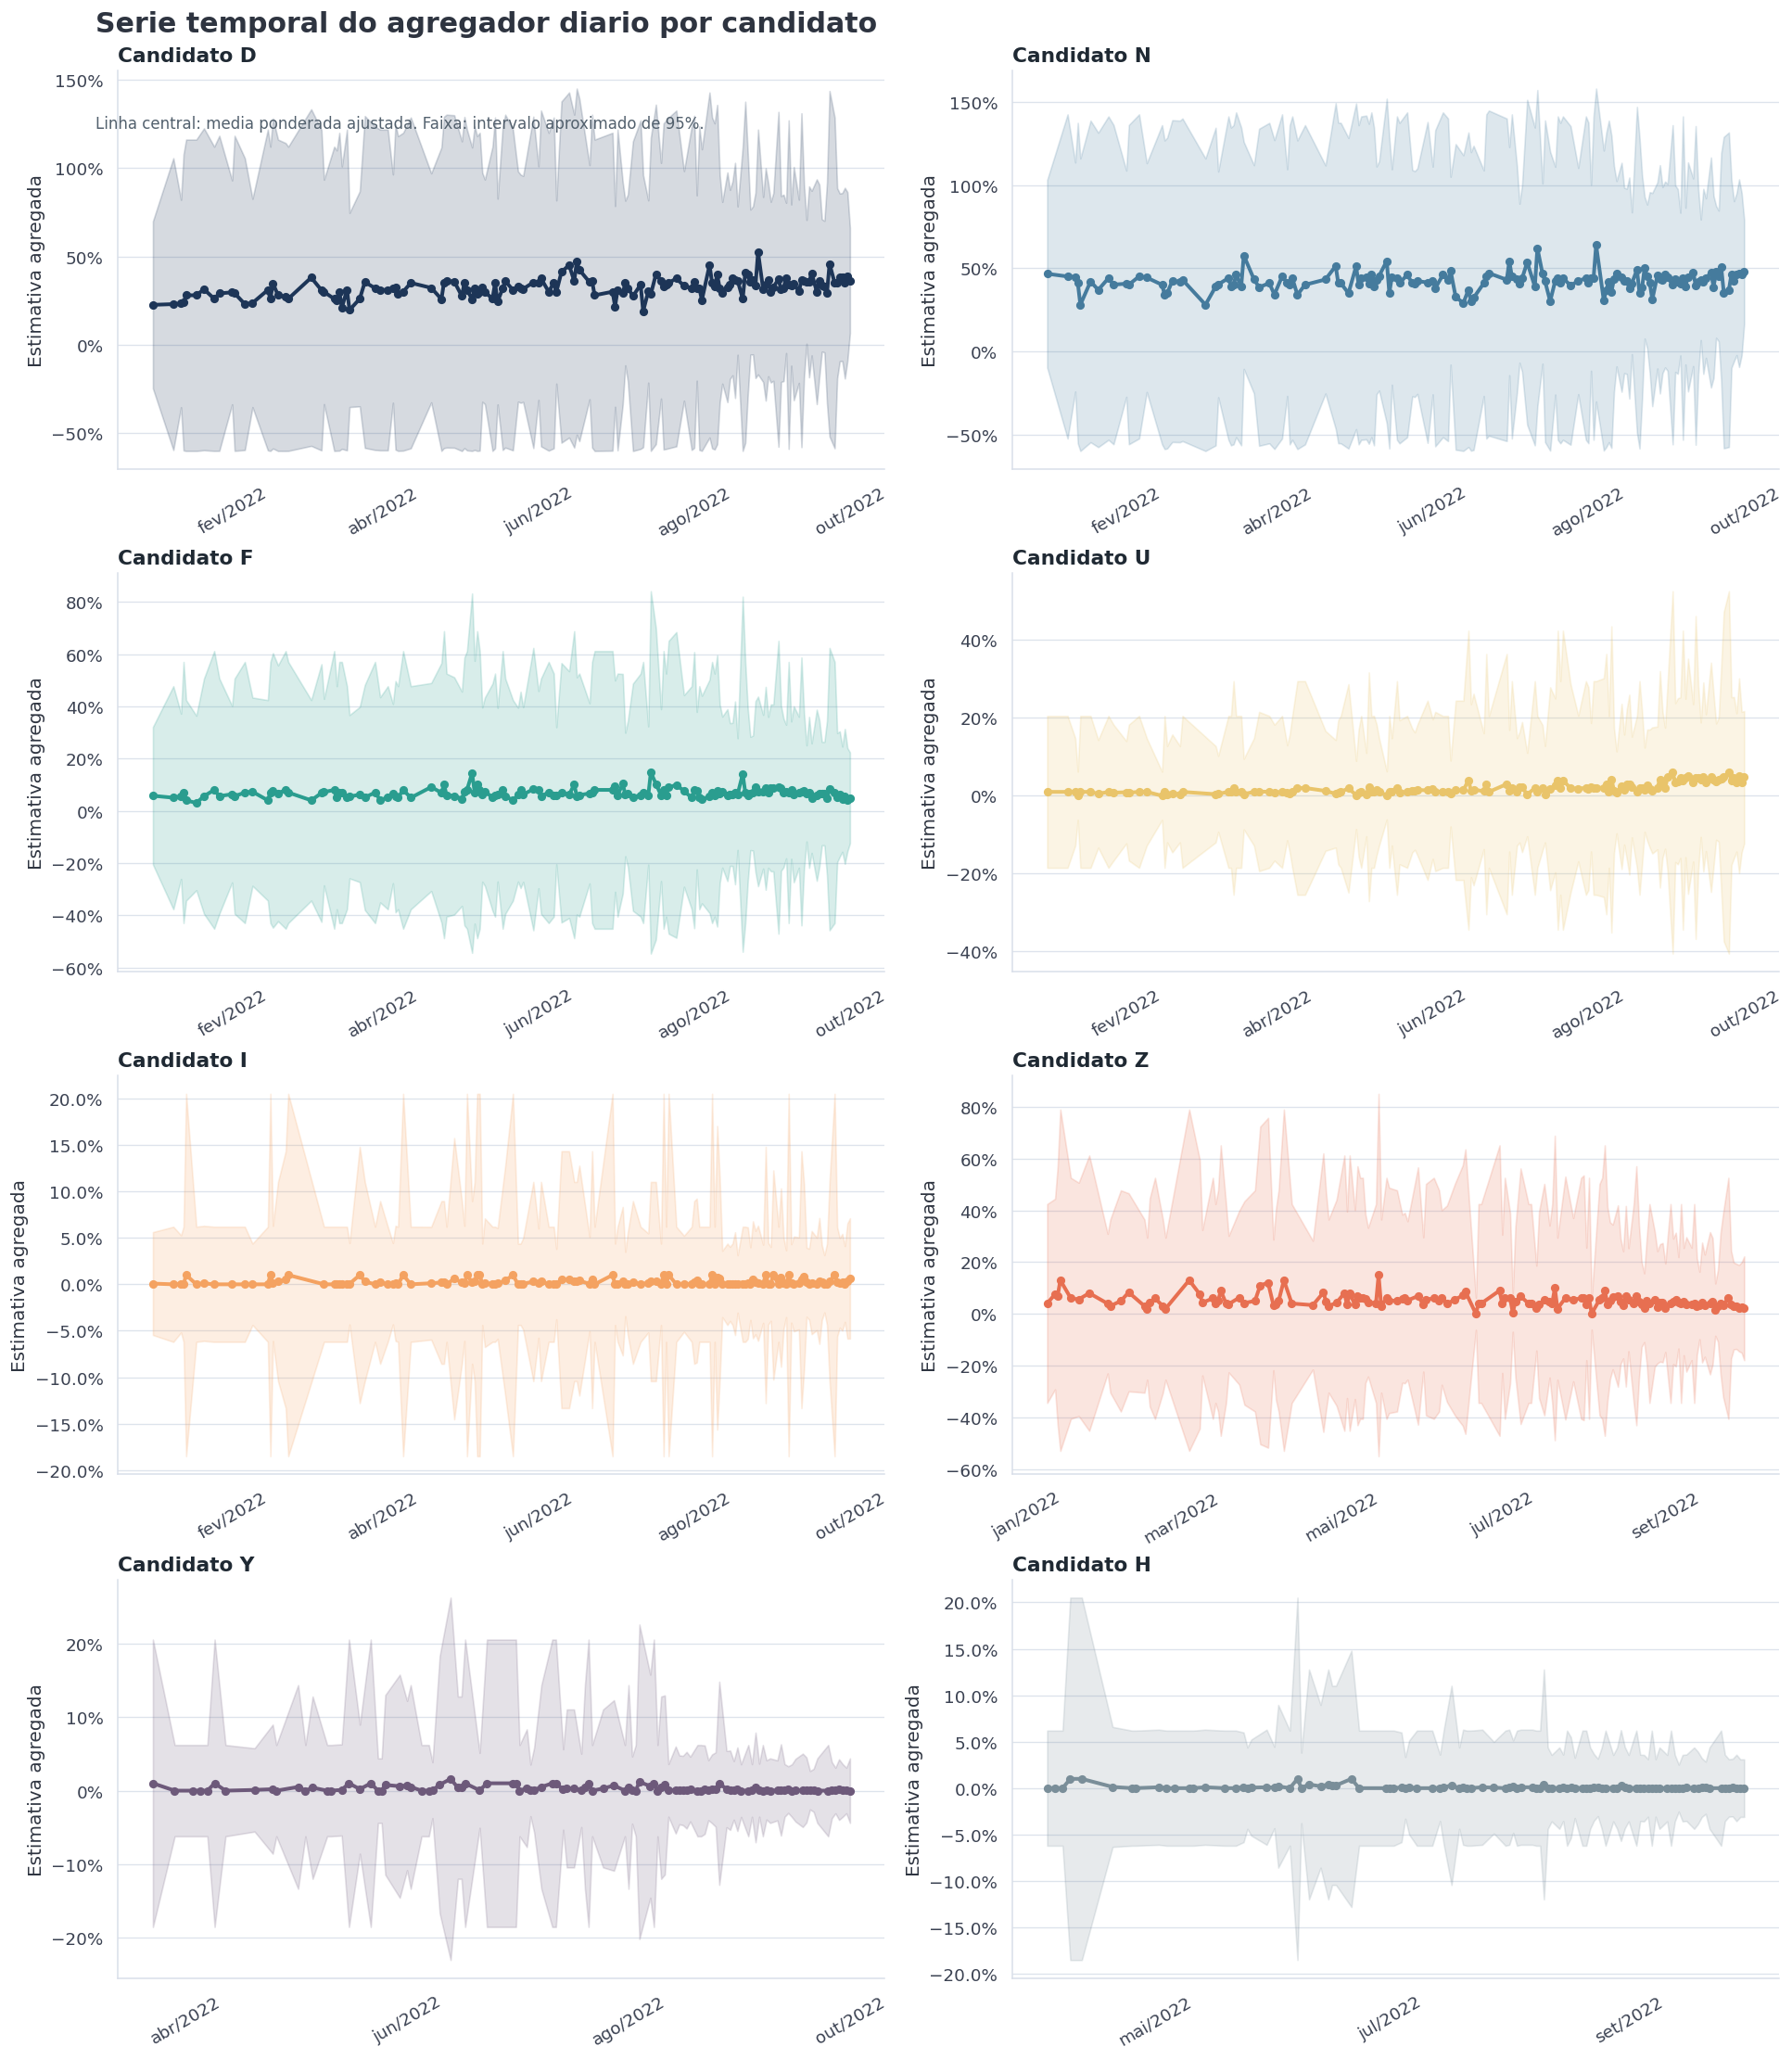

2026-04-30 17:06:29,834 - INFO - Arquivo registrado: histograma_ict.png
2026-04-30 17:06:29,836 - INFO - Gráfico salvo com sucesso: histograma_ict.png


Grafico salvo: histograma_ict.png


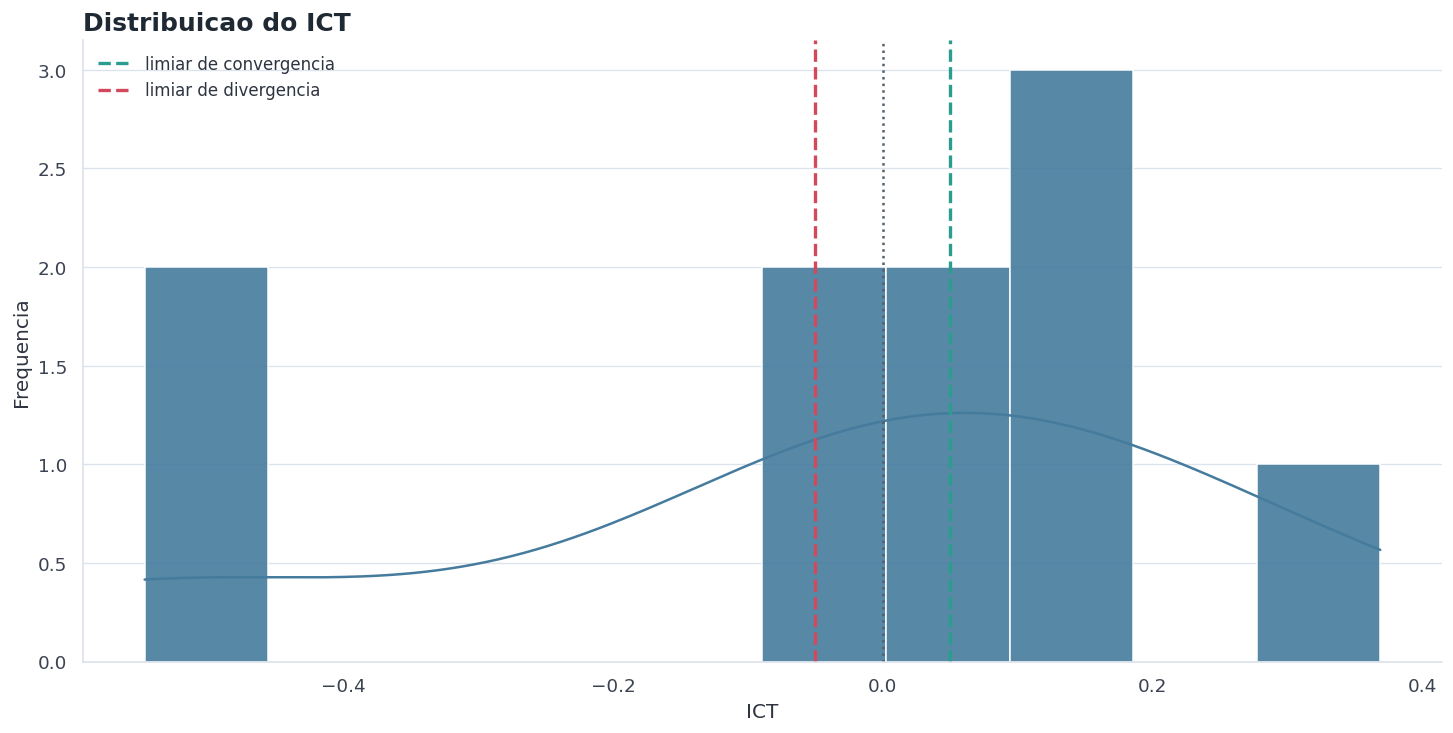

2026-04-30 17:06:31,103 - INFO - Arquivo registrado: boxplot_ict_por_classe.png
2026-04-30 17:06:31,105 - INFO - Gráfico salvo com sucesso: boxplot_ict_por_classe.png


Grafico salvo: boxplot_ict_por_classe.png


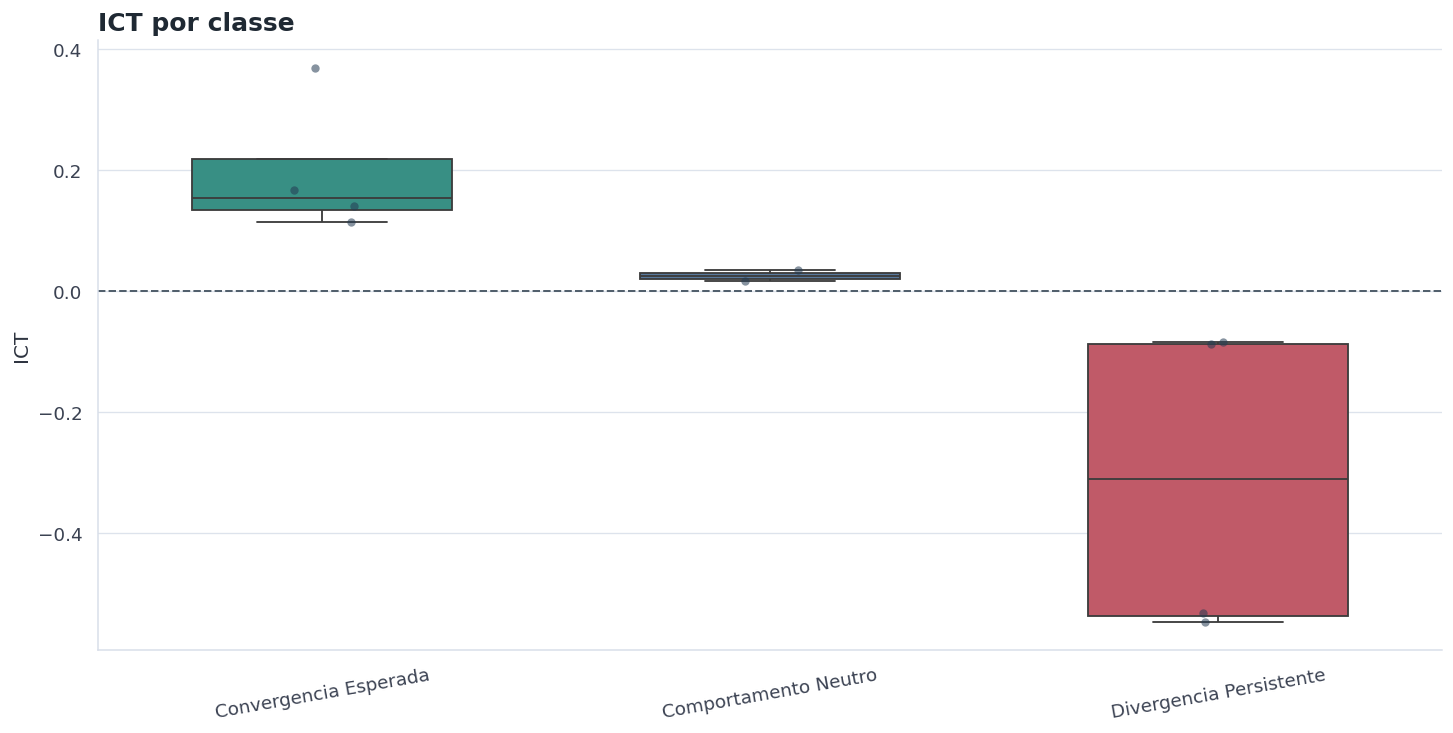

2026-04-30 17:06:32,781 - INFO - Arquivo registrado: barras_ict_por_instituto.png
2026-04-30 17:06:32,783 - INFO - Gráfico salvo com sucesso: barras_ict_por_instituto.png


Grafico salvo: barras_ict_por_instituto.png


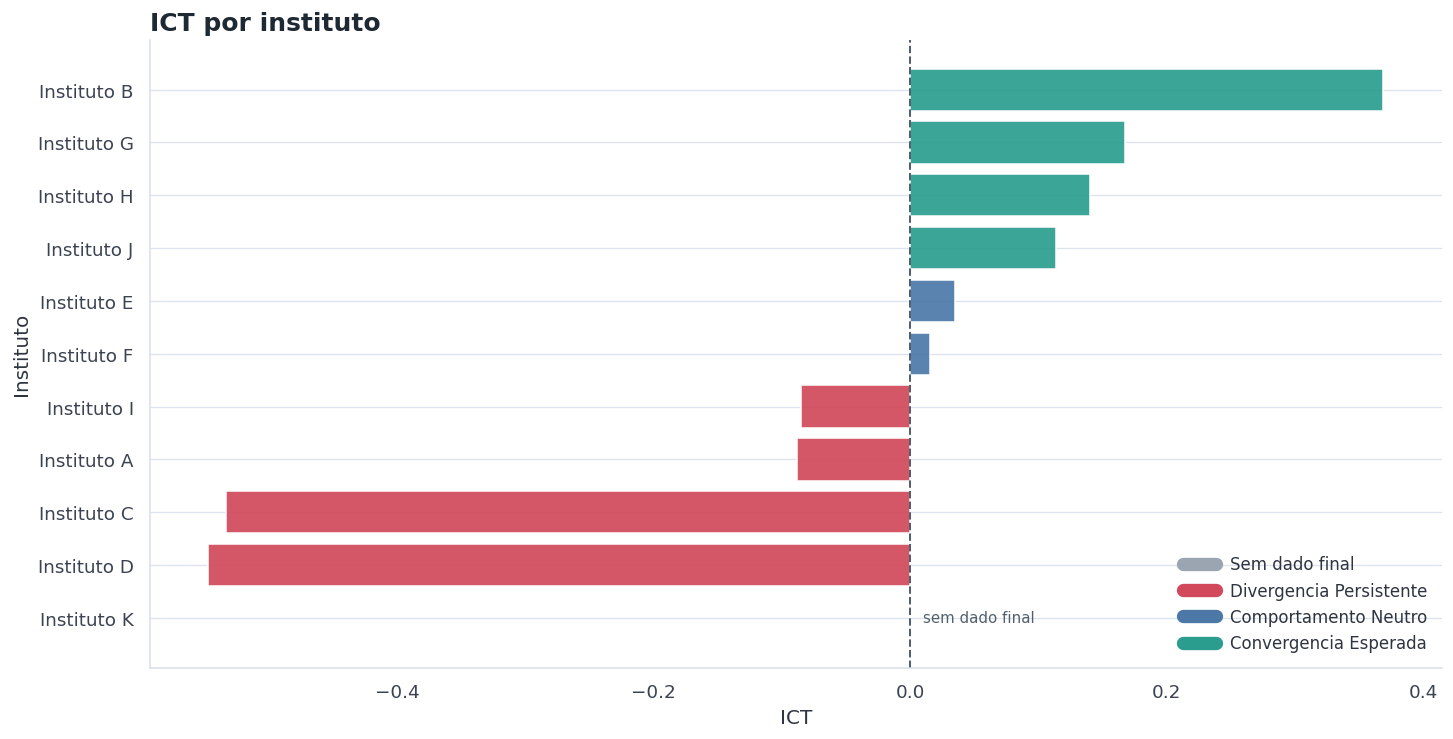

2026-04-30 17:06:34,699 - INFO - Arquivo registrado: distancia_inicial_vs_final.png
2026-04-30 17:06:34,701 - INFO - Gráfico salvo com sucesso: distancia_inicial_vs_final.png


Grafico salvo: distancia_inicial_vs_final.png


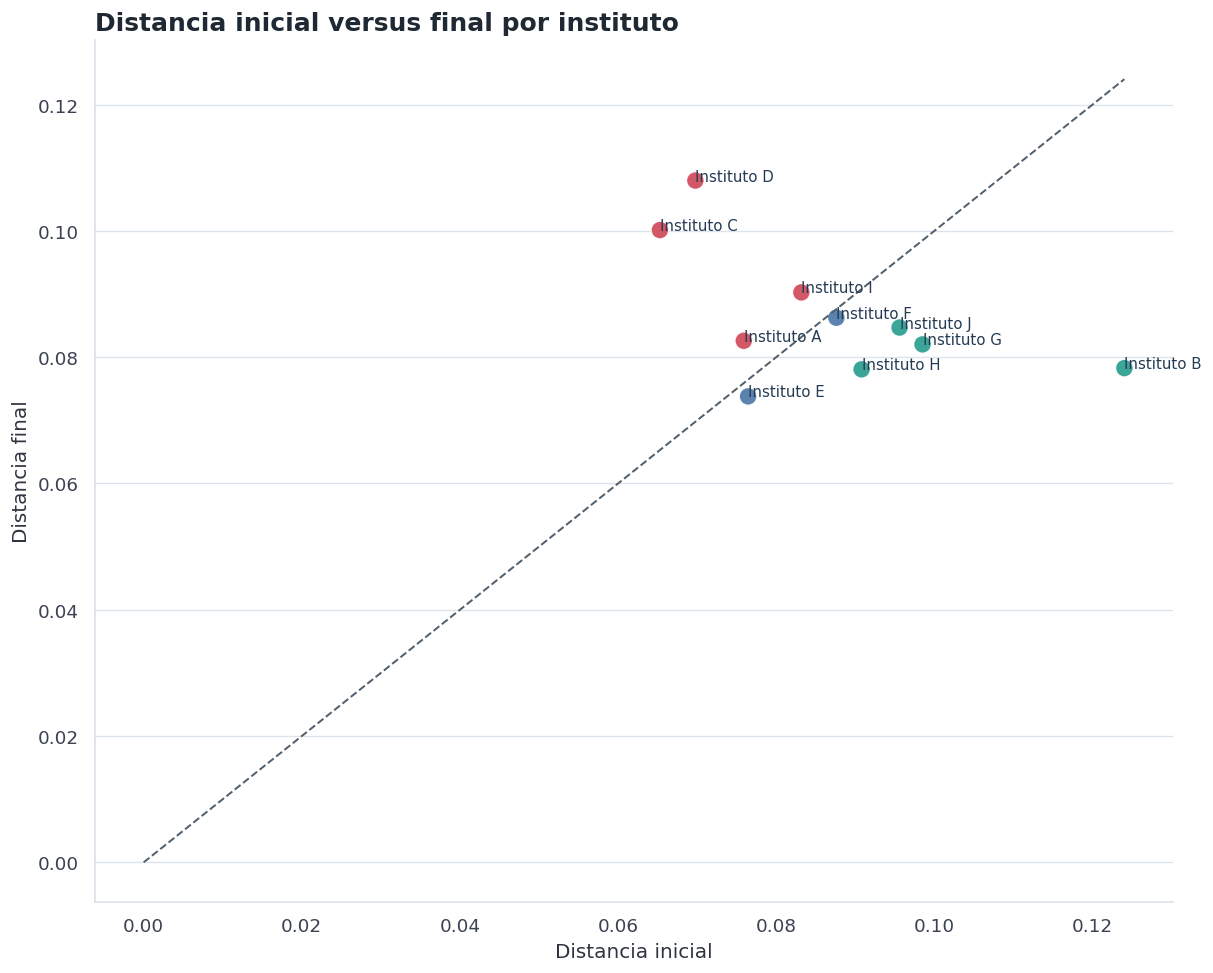

2026-04-30 17:06:37,263 - INFO - Arquivo registrado: heatmap_instituto_bimestres.png
2026-04-30 17:06:37,265 - INFO - Gráfico salvo com sucesso: heatmap_instituto_bimestres.png


Grafico salvo: heatmap_instituto_bimestres.png


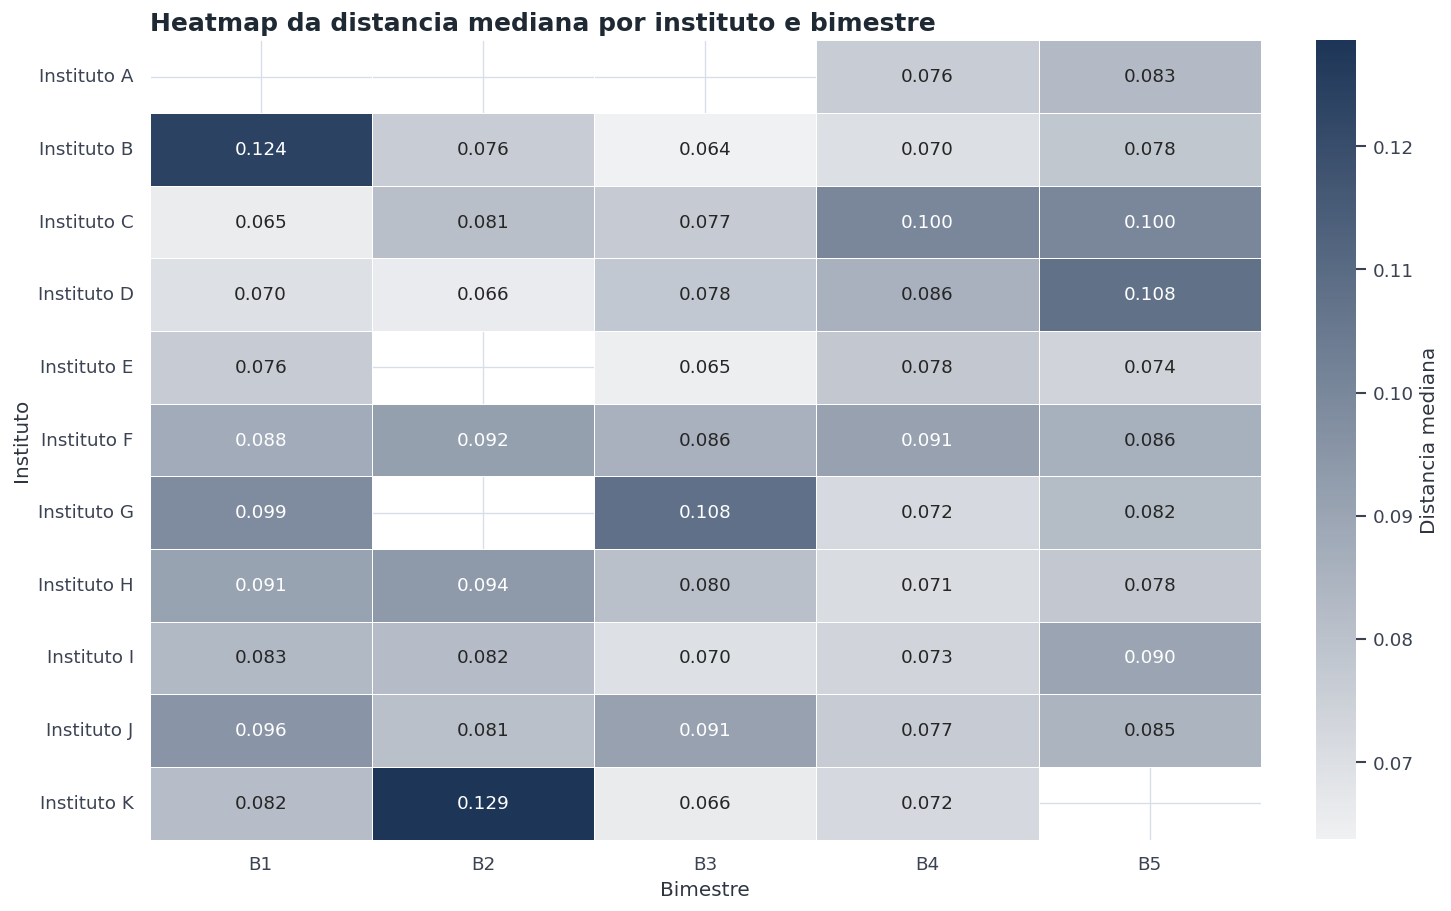

✓ Gráficos originais gerados


In [73]:
# ============================================================================
# GRÁFICOS ORIGINAIS
# ============================================================================

logger.info("Gerando gráficos...")
print("\n" + "="*80)
print("GERANDO GRÁFICOS ORIGINAIS")
print("="*80)

if not agregador_final.empty:
    agregador_plot = agregador_final.copy()
    agregador_plot["serie_label"] = agregador_plot["candidato"].astype(str)
    if agregador_plot["tipo_de_votos"].nunique(dropna=True) > 1:
        agregador_plot["serie_label"] = agregador_plot["candidato"].astype(str) + " | " + agregador_plot["tipo_de_votos"].astype(str)

    top_series = (
        agregador_plot.groupby("serie_label")["quantidade_pesquisas_agregadas"]
        .sum()
        .sort_values(ascending=False)
        .head(8)
        .index
        .tolist()
    )
    plot_df = agregador_plot[agregador_plot["serie_label"].isin(top_series)].copy()
    n_plots, n_cols = max(len(top_series), 1), 2
    n_rows = math.ceil(n_plots / n_cols)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4.6 * n_rows), constrained_layout=True)
    axes = np.atleast_1d(axes).ravel()
    cores_series = sns.color_palette(PALETA_ARTIGO, n_colors=max(len(top_series), 1))

    for ax, label, cor in zip(axes, top_series, cores_series):
        tmp = plot_df.loc[plot_df["serie_label"] == label].sort_values("data")
        ax.plot(tmp["data"], tmp["media_final"], marker="o", markersize=4.5, linewidth=2.4, color=cor)
        ax.fill_between(tmp["data"], tmp["limite_inferior"], tmp["limite_superior"], color=cor, alpha=0.18)
        ax.set_title(wrap_label(label, 30), loc="left", fontsize=13, fontweight="bold")
        ax.set_ylabel("Estimativa agregada")
        ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%b/%Y"))
        ax.tick_params(axis="x", rotation=30)
        estilizar_eixo(ax, eixo_percentual="y")

    for ax in axes[len(top_series):]:
        ax.axis("off")

    fig.suptitle("Serie temporal do agregador diario por candidato", x=0.05, ha="left", fontsize=18, fontweight="bold")
    fig.text(0.05, 0.94, "Linha central: media ponderada ajustada. Faixa: intervalo aproximado de 95%.", fontsize=10, color="#52606D")
    salvar_figura(fig, "agregador_diario_por_candidato.png")
    plt.show()

if not resultado_ict_institutos.empty:
    ict_validos = resultado_ict_institutos.dropna(subset=["ict"]).copy()

    if not ict_validos.empty:
        fig, ax = plt.subplots(figsize=(12, 6), constrained_layout=True)
        sns.histplot(
            ict_validos["ict"],
            bins=min(10, max(4, len(ict_validos))),
            kde=ict_validos["ict"].nunique() > 1,
            ax=ax,
            color=PALETA_ARTIGO[1],
            edgecolor="white",
            linewidth=0.9,
            alpha=0.9,
        )
        ax.axvline(0.05, color=CLASS_COLOR_MAP["Convergencia Esperada"], linestyle="--", linewidth=2, label="limiar de convergencia")
        ax.axvline(-0.05, color=CLASS_COLOR_MAP["Divergencia Persistente"], linestyle="--", linewidth=2, label="limiar de divergencia")
        ax.axvline(0, color="#52606D", linestyle=":", linewidth=1.5)
        ax.set_title("Distribuicao do ICT", loc="left")
        ax.set_xlabel("ICT")
        ax.set_ylabel("Frequencia")
        estilizar_eixo(ax)
        ax.legend(loc="upper left")
        salvar_figura(fig, "histograma_ict.png")
        plt.show()

        ordem_classes = [
            classe for classe in ["Convergencia Esperada", "Comportamento Neutro", "Divergencia Persistente"]
            if classe in ict_validos["classificacao"].dropna().unique()
        ]
        if ordem_classes:
            fig, ax = plt.subplots(figsize=(12, 6), constrained_layout=True)
            palette_box = {classe: CLASS_COLOR_MAP.get(classe, PALETA_ARTIGO[0]) for classe in ordem_classes}
            sns.boxplot(
                data=ict_validos,
                x="classificacao",
                y="ict",
                order=ordem_classes,
                palette=palette_box,
                width=0.58,
                linewidth=1.1,
                fliersize=0,
                ax=ax,
            )
            sns.stripplot(
                data=ict_validos,
                x="classificacao",
                y="ict",
                order=ordem_classes,
                color="#243B53",
                size=5,
                alpha=0.55,
                ax=ax,
            )
            ax.axhline(0, color="#52606D", linestyle="--", linewidth=1.2)
            ax.set_title("ICT por classe", loc="left")
            ax.set_xlabel("")
            ax.set_ylabel("ICT")
            estilizar_eixo(ax)
            ax.tick_params(axis="x", rotation=10)
            salvar_figura(fig, "boxplot_ict_por_classe.png")
            plt.show()

    barras_df = resultado_ict_institutos.copy()
    barras_df["classificacao_plot"] = barras_df["classificacao"].fillna("ICT indefinido")
    barras_df = barras_df.sort_values("ict", ascending=True, na_position="first").reset_index(drop=True)
    barras_df["ict_plot"] = barras_df["ict"].fillna(0.0)
    fig, ax = plt.subplots(figsize=(12, max(6, 0.55 * len(barras_df))), constrained_layout=True)
    cores_barras = barras_df["classificacao_plot"].map(CLASS_COLOR_MAP).fillna("#9AA5B1")
    ax.barh(barras_df["instituto"], barras_df["ict_plot"], color=cores_barras, alpha=0.92)
    ax.axvline(0, color="#52606D", linestyle="--", linewidth=1.2)
    for y_pos, linha in barras_df.iterrows():
        if pd.isna(linha["ict"]):
            ax.text(0.01, y_pos, "sem dado final", va="center", ha="left", fontsize=9, color="#52606D")
    ax.set_title("ICT por instituto", loc="left")
    ax.set_xlabel("ICT")
    ax.set_ylabel("Instituto")
    estilizar_eixo(ax)
    legendas = []
    for classe in barras_df["classificacao_plot"].dropna().unique():
        legendas.append(Line2D([0], [0], color=CLASS_COLOR_MAP.get(classe, "#9AA5B1"), lw=8, label=classe))
    if legendas:
        ax.legend(handles=legendas, loc="lower right")
    salvar_figura(fig, "barras_ict_por_instituto.png")
    plt.show()

    fig, ax = plt.subplots(figsize=(10, 8), constrained_layout=True)
    cores_scatter = resultado_ict_institutos["classificacao"].map(CLASS_COLOR_MAP).fillna("#9AA5B1")
    ax.scatter(
        resultado_ict_institutos["distancia_inicial"],
        resultado_ict_institutos["distancia_final"],
        s=115,
        c=cores_scatter,
        alpha=0.92,
        edgecolors="white",
        linewidth=0.9,
    )
    limite_max = np.nanmax([
        resultado_ict_institutos["distancia_inicial"].max(),
        resultado_ict_institutos["distancia_final"].max(),
        0.01,
    ])
    ax.plot([0, limite_max], [0, limite_max], linestyle="--", color="#52606D", linewidth=1.2)
    for _, linha in resultado_ict_institutos.iterrows():
        if pd.notna(linha["distancia_inicial"]) and pd.notna(linha["distancia_final"]):
            ax.text(linha["distancia_inicial"], linha["distancia_final"], linha["instituto"], fontsize=9, color="#243B53")
    ax.set_title("Distancia inicial versus final por instituto", loc="left")
    ax.set_xlabel("Distancia inicial")
    ax.set_ylabel("Distancia final")
    estilizar_eixo(ax)
    salvar_figura(fig, "distancia_inicial_vs_final.png")
    plt.show()

if not pivot_bimestres.empty:
    matriz_heatmap = pivot_bimestres[ordem_bimestres]
    fig, ax = plt.subplots(figsize=(12, max(5, 0.68 * len(matriz_heatmap))), constrained_layout=True)
    sns.heatmap(
        matriz_heatmap,
        cmap=sns.light_palette("#1D3557", as_cmap=True),
        annot=True,
        fmt=".3f",
        linewidths=0.6,
        linecolor="white",
        cbar_kws={"label": "Distancia mediana"},
        ax=ax,
    )
    ax.set_title("Heatmap da distancia mediana por instituto e bimestre", loc="left")
    ax.set_xlabel("Bimestre")
    ax.set_ylabel("Instituto")
    ax.tick_params(axis="x", rotation=0)
    ax.tick_params(axis="y", rotation=0)
    salvar_figura(fig, "heatmap_instituto_bimestres.png")
    plt.show()


print("✓ Gráficos originais gerados")


## 11. Novos Gráficos Avançados (NOVO)

Sete novos gráficos para demonstrar o ICT de forma abrangente.


In [74]:
# ============================================================================
# NOVOS GRÁFICOS AVANÇADOS
# ============================================================================

print("\n" + "="*80)
print("GERANDO NOVOS GRÁFICOS AVANÇADOS")
print("="*80)

# ============================================================================
# GRÁFICO 1: Série Temporal do ICT por Instituto
# ============================================================================

logger.info("Gerando gráfico: Série Temporal do ICT")

fig, ax = plt.subplots(figsize=(14, 8))

# Preparar dados para série temporal
ict_temporal = resultado_ict_institutos[['instituto', 'instituto_id'] + ordem_bimestres].set_index('instituto')

# Plotar linha para cada instituto
for idx, instituto in enumerate(ict_temporal.index):
    valores = ict_temporal.loc[instituto, ordem_bimestres].values
    cor = PALETA_ARTIGO[idx % len(PALETA_ARTIGO)]
    ax.plot(range(len(ordem_bimestres)), valores, marker='o', label=instituto, 
            color=cor, linewidth=2.5, markersize=8, alpha=0.8)

# Adicionar linhas de referência
ax.axhline(y=0.05, color='#2A9D8F', linestyle='--', linewidth=1.5, alpha=0.5, label='Limiar Convergência (0.05)')
ax.axhline(y=-0.05, color='#D1495B', linestyle='--', linewidth=1.5, alpha=0.5, label='Limiar Divergência (-0.05)')
ax.axhline(y=0, color='#4C78A8', linestyle='-', linewidth=1, alpha=0.3, label='Neutralidade (0.00)')

# Sombreamento das regiões
ax.fill_between(range(len(ordem_bimestres)), 0.05, 1, alpha=0.1, color='#2A9D8F')
ax.fill_between(range(len(ordem_bimestres)), -0.05, 0.05, alpha=0.1, color='#4C78A8')
ax.fill_between(range(len(ordem_bimestres)), -1, -0.05, alpha=0.1, color='#D1495B')

# Configuração dos eixos
ax.set_xticks(range(len(ordem_bimestres)))
ax.set_xticklabels(ordem_bimestres, rotation=45)
ax.set_xlabel('Bimestre', fontsize=12, fontweight='bold')
ax.set_ylabel('Indicador de Convergência Temporal (ICT)', fontsize=12, fontweight='bold')
ax.set_title('Evolução Temporal do ICT por Instituto', fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='best', fontsize=9, ncol=2)
ax.grid(True, alpha=0.3, axis='y')
estilizar_eixo(ax)

plt.tight_layout()
salvar_figura(fig, 'ict_01_serie_temporal_por_instituto.png')
plt.close()

# ============================================================================
# GRÁFICO 2: Distribuição do ICT por Categoria (Violino)
# ============================================================================

logger.info("Gerando gráfico: Distribuição Violino")

fig, ax = plt.subplots(figsize=(12, 7))

# Preparar dados
dados_violino = []
categorias = []
cores_violino = []

for classe in ['Convergencia Esperada', 'Comportamento Neutro', 'Divergencia Persistente']:
    valores = resultado_ict_institutos[resultado_ict_institutos['classificacao'] == classe]['ict'].dropna().values
    if len(valores) > 0:
        dados_violino.append(valores)
        categorias.append(classe)
        cores_violino.append(CLASS_COLOR_MAP.get(classe, '#999999'))

# Criar violino
parts = ax.violinplot(dados_violino, positions=range(len(categorias)), widths=0.7, 
                      showmeans=True, showmedians=True)

# Colorir violinos
for pc, cor in zip(parts['bodies'], cores_violino):
    pc.set_facecolor(cor)
    pc.set_alpha(0.7)

# Sobrepor pontos individuais
for i, valores in enumerate(dados_violino):
    y = valores
    x = np.random.normal(i, 0.04, size=len(y))
    ax.scatter(x, y, alpha=0.5, s=50, color=cores_violino[i])

# Configuração
ax.set_xticks(range(len(categorias)))
ax.set_xticklabels(categorias, rotation=15, ha='right')
ax.set_ylabel('Valor do ICT', fontsize=12, fontweight='bold')
ax.set_title('Distribuição do ICT por Categoria Comportamental', fontsize=14, fontweight='bold', pad=20)
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.8, alpha=0.5)
ax.grid(True, alpha=0.3, axis='y')
estilizar_eixo(ax)

plt.tight_layout()
salvar_figura(fig, 'ict_02_distribuicao_violino_por_categoria.png')
plt.close()

# ============================================================================
# GRÁFICO 3: Heatmap Instituto-Bimestre
# ============================================================================

logger.info("Gerando gráfico: Heatmap")

fig, ax = plt.subplots(figsize=(12, 8))

# Preparar matriz
matriz_ict = resultado_ict_institutos[['instituto'] + ordem_bimestres].set_index('instituto')

# Criar heatmap
sns.heatmap(matriz_ict, annot=True, fmt='.3f', cmap='RdYlGn', center=0, 
            cbar_kws={'label': 'ICT'}, ax=ax, linewidths=0.5, linecolor='white',
            vmin=-0.15, vmax=0.15)

ax.set_title('Matriz Instituto-Bimestre: Valores de ICT', fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Bimestre', fontsize=12, fontweight='bold')
ax.set_ylabel('Instituto', fontsize=12, fontweight='bold')
plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()
salvar_figura(fig, 'ict_03_heatmap_instituto_bimestre.png')
plt.close()

# ============================================================================
# GRÁFICO 4: Dispersão ICT vs Distância Final
# ============================================================================

logger.info("Gerando gráfico: Dispersão")

fig, ax = plt.subplots(figsize=(12, 8))

# Preparar dados
dados_dispersao = resultado_ict_institutos[resultado_ict_institutos['classificacao'] != 'Sem dado final'].copy()

# Plotar por categoria
for classe in ['Convergencia Esperada', 'Comportamento Neutro', 'Divergencia Persistente']:
    subset = dados_dispersao[dados_dispersao['classificacao'] == classe]
    cor = CLASS_COLOR_MAP.get(classe, '#999999')
    ax.scatter(subset['distancia_final'], subset['ict'], 
              label=classe, color=cor, s=150, alpha=0.7, edgecolors='black', linewidth=1.5)

# Linha de tendência
z = np.polyfit(dados_dispersao['distancia_final'].dropna(), 
               dados_dispersao['ict'].dropna(), 1)
p = np.poly1d(z)
x_trend = np.linspace(dados_dispersao['distancia_final'].min(), 
                      dados_dispersao['distancia_final'].max(), 100)
ax.plot(x_trend, p(x_trend), "k--", alpha=0.5, linewidth=2, label='Tendência Linear')

# Linhas de referência
ax.axhline(y=0.05, color='#2A9D8F', linestyle=':', alpha=0.5, linewidth=1.5)
ax.axhline(y=-0.05, color='#D1495B', linestyle=':', alpha=0.5, linewidth=1.5)
ax.axhline(y=0, color='#4C78A8', linestyle='-', alpha=0.3, linewidth=1)

# Configuração
ax.set_xlabel('Distância Final ao Consenso (pp)', fontsize=12, fontweight='bold')
ax.set_ylabel('Indicador de Convergência Temporal (ICT)', fontsize=12, fontweight='bold')
ax.set_title('Relação entre ICT e Distância Final ao Consenso', fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='best', fontsize=10)
ax.grid(True, alpha=0.3)
estilizar_eixo(ax)

plt.tight_layout()
salvar_figura(fig, 'ict_04_dispersao_ict_vs_distancia_final.png')
plt.close()

# ============================================================================
# GRÁFICO 5: Barras Horizontais de Classificação Final
# ============================================================================

logger.info("Gerando gráfico: Barras de Classificação")

fig, ax = plt.subplots(figsize=(12, 8))

# Preparar dados
dados_barras = resultado_ict_institutos[resultado_ict_institutos['classificacao'] != 'Sem dado final'].copy()
dados_barras = dados_barras.sort_values('ict', ascending=True)

# Cores
cores = [CLASS_COLOR_MAP.get(classe, '#999999') for classe in dados_barras['classificacao']]

# Barras
barras = ax.barh(dados_barras['instituto'], dados_barras['ict'], color=cores, alpha=0.8, edgecolor='black', linewidth=1.5)

# Valores nas barras
for i, (idx, row) in enumerate(dados_barras.iterrows()):
    valor = row['ict']
    ax.text(valor + 0.005 if valor > 0 else valor - 0.005, i, f'{valor:.4f}', 
            va='center', ha='left' if valor > 0 else 'right', fontsize=9, fontweight='bold')

# Linhas de referência
ax.axvline(x=0.05, color='#2A9D8F', linestyle='--', linewidth=2, alpha=0.7, label='Limiar Convergência')
ax.axvline(x=-0.05, color='#D1495B', linestyle='--', linewidth=2, alpha=0.7, label='Limiar Divergência')
ax.axvline(x=0, color='#4C78A8', linestyle='-', linewidth=1.5, alpha=0.5, label='Neutralidade')

# Configuração
ax.set_xlabel('Indicador de Convergência Temporal (ICT)', fontsize=12, fontweight='bold')
ax.set_ylabel('Instituto', fontsize=12, fontweight='bold')
ax.set_title('Classificação Final dos Institutos por ICT', fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='best', fontsize=10)
ax.grid(True, alpha=0.3, axis='x')
estilizar_eixo(ax)

plt.tight_layout()
salvar_figura(fig, 'ict_05_barras_classificacao_final.png')
plt.close()

# ============================================================================
# GRÁFICO 6: Proporção de Institutos por Categoria ao Longo do Tempo
# ============================================================================

logger.info("Gerando gráfico: Proporção Temporal")

fig, ax = plt.subplots(figsize=(13, 7))

# Preparar dados para área empilhada
proporcoes = []
for bimestre in ordem_bimestres:
    total = len(resultado_ict_institutos)
    convergencia = len(resultado_ict_institutos[resultado_ict_institutos['classificacao'] == 'Convergencia Esperada'])
    neutro = len(resultado_ict_institutos[resultado_ict_institutos['classificacao'] == 'Comportamento Neutro'])
    divergencia = len(resultado_ict_institutos[resultado_ict_institutos['classificacao'] == 'Divergencia Persistente'])
    proporcoes.append([convergencia/total if total > 0 else 0, 
                      neutro/total if total > 0 else 0, 
                      divergencia/total if total > 0 else 0])

proporcoes = np.array(proporcoes).T

# Criar área empilhada
ax.stackplot(range(len(ordem_bimestres)), proporcoes[0], proporcoes[1], proporcoes[2],
            labels=['Convergência Esperada', 'Comportamento Neutro', 'Divergência Persistente'],
            colors=['#2A9D8F', '#4C78A8', '#D1495B'], alpha=0.8)

# Configuração
ax.set_xticks(range(len(ordem_bimestres)))
ax.set_xticklabels(ordem_bimestres, rotation=45)
ax.set_xlabel('Bimestre', fontsize=12, fontweight='bold')
ax.set_ylabel('Proporção de Institutos', fontsize=12, fontweight='bold')
ax.set_title('Evolução da Proporção de Institutos por Categoria Comportamental', 
            fontsize=14, fontweight='bold', pad=20)
ax.set_ylim([0, 1])
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.legend(loc='upper left', fontsize=10)
ax.grid(True, alpha=0.3, axis='y')
estilizar_eixo(ax, eixo_percentual='y')

plt.tight_layout()
salvar_figura(fig, 'ict_06_area_proporcao_categorias_temporal.png')
plt.close()

# ============================================================================
# GRÁFICO 7: Boxplot de Distância ao Consenso por Instituto
# ============================================================================

logger.info("Gerando gráfico: Boxplot")

fig, ax = plt.subplots(figsize=(14, 8))

# Preparar dados
dados_boxplot = []
labels_boxplot = []
cores_boxplot = []

for instituto in resultado_ict_institutos['instituto'].unique():
    subset = distancias_por_instituto_bimestre[distancias_por_instituto_bimestre['instituto'] == instituto]
    if len(subset) > 0:
        dados_boxplot.append(subset['media_distancia'].dropna().values)
        labels_boxplot.append(instituto)
        classificacao = resultado_ict_institutos[resultado_ict_institutos['instituto'] == instituto]['classificacao'].values[0]
        cores_boxplot.append(CLASS_COLOR_MAP.get(classificacao, '#999999'))

# Criar boxplot
bp = ax.boxplot(dados_boxplot, labels=labels_boxplot, patch_artist=True, 
               vert=True, widths=0.6)

# Colorir boxes
for patch, cor in zip(bp['boxes'], cores_boxplot):
    patch.set_facecolor(cor)
    patch.set_alpha(0.7)

# Configuração
ax.set_xlabel('Instituto', fontsize=12, fontweight='bold')
ax.set_ylabel('Distância Absoluta ao Consenso (pp)', fontsize=12, fontweight='bold')
ax.set_title('Distribuição da Distância ao Consenso por Instituto', fontsize=14, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
ax.grid(True, alpha=0.3, axis='y')
estilizar_eixo(ax)

plt.tight_layout()
salvar_figura(fig, 'ict_07_boxplot_distancia_consenso_por_instituto.png')
plt.close()

print("\n✓ Todos os 7 novos gráficos gerados com sucesso!")
logger.info("Novos gráficos gerados com sucesso")


2026-04-30 17:06:38,085 - INFO - Gerando gráfico: Série Temporal do ICT



GERANDO NOVOS GRÁFICOS AVANÇADOS


2026-04-30 17:06:39,556 - INFO - Arquivo registrado: ict_01_serie_temporal_por_instituto.png
2026-04-30 17:06:39,558 - INFO - Gráfico salvo com sucesso: ict_01_serie_temporal_por_instituto.png
2026-04-30 17:06:39,560 - INFO - Gerando gráfico: Distribuição Violino


Grafico salvo: ict_01_serie_temporal_por_instituto.png


2026-04-30 17:06:41,334 - INFO - Arquivo registrado: ict_02_distribuicao_violino_por_categoria.png
2026-04-30 17:06:41,338 - INFO - Gráfico salvo com sucesso: ict_02_distribuicao_violino_por_categoria.png
2026-04-30 17:06:41,340 - INFO - Gerando gráfico: Heatmap


...

Grafico salvo: ict_05_barras_classificacao_final.png


2026-04-30 17:06:49,319 - INFO - Arquivo registrado: ict_06_area_proporcao_categorias_temporal.png
2026-04-30 17:06:49,338 - INFO - Gráfico salvo com sucesso: ict_06_area_proporcao_categorias_temporal.png
2026-04-30 17:06:49,344 - INFO - Gerando gráfico: Boxplot


Grafico salvo: ict_06_area_proporcao_categorias_temporal.png


2026-04-30 17:06:51,982 - INFO - Arquivo registrado: ict_07_boxplot_distancia_consenso_por_instituto.png
2026-04-30 17:06:52,056 - INFO - Gráfico salvo com sucesso: ict_07_boxplot_distancia_consenso_por_instituto.png
2026-04-30 17:06:52,081 - INFO - Novos gráficos gerados com sucesso


Grafico salvo: ict_07_boxplot_distancia_consenso_por_instituto.png

✓ Todos os 7 novos gráficos gerados com sucesso!


## 12. Exportação de Saídas

Exportação estruturada de resultados em múltiplos formatos.


In [75]:
# ============================================================================
# EXPORTAÇÃO DE SAÍDAS
# ============================================================================

logger.info("Iniciando exportação de resultados...")

try:
    # Exportar CSVs
    resultado_ict_institutos.to_csv(OUTPUT_DIR / "resultado_ict_institutos.csv", index=False)
    registrar_arquivo(OUTPUT_DIR / "resultado_ict_institutos.csv")
    
    distancias_por_instituto_bimestre.to_csv(OUTPUT_DIR / "distancias_por_instituto_bimestre.csv", index=False)
    registrar_arquivo(OUTPUT_DIR / "distancias_por_instituto_bimestre.csv")
    
    # Exportar Excel consolidado
    excel_path = OUTPUT_DIR / "consolidado_agregador_ict.xlsx"
    with pd.ExcelWriter(excel_path, engine="openpyxl") as writer:
        resultado_ict_institutos.to_excel(writer, sheet_name="ict_final", index=False)
        estatisticas_testes_ict.to_excel(writer, sheet_name="testes_estatisticos", index=False)
    registrar_arquivo(excel_path)
    
    logger.info("Exportação concluída com sucesso")
    print("✓ Resultados exportados com sucesso")
    
except Exception as e:
    logger.error(f"Erro ao exportar resultados: {e}")
    raise


2026-04-30 17:06:52,339 - INFO - Iniciando exportação de resultados...
2026-04-30 17:06:52,776 - INFO - Arquivo registrado: resultado_ict_institutos.csv
2026-04-30 17:06:53,178 - INFO - Arquivo registrado: distancias_por_instituto_bimestre.csv
2026-04-30 17:06:53,298 - INFO - Arquivo registrado: consolidado_agregador_ict.xlsx
2026-04-30 17:06:53,302 - INFO - Exportação concluída com sucesso


✓ Resultados exportados com sucesso


## 13. Resumo Final Automático

Sumário executivo com principais decisões e resultados.


In [76]:
# ============================================================================
# RESUMO FINAL AUTOMÁTICO
# ============================================================================

logger.info("Gerando resumo final...")

contagem_classes = resultado_ict_institutos["classificacao"].value_counts()
contagem_situacao = resultado_ict_institutos["classificacao"].value_counts()

display(Markdown(f"""
## RESUMO FINAL DA ANÁLISE

### Dados de Entrada
- **Base localizada:** {fonte_base_limpa}
- **Registros iniciais:** {base_limpa.shape[0]:,}
- **Período analisado:** {data_min.date()} a {data_max.date()} ({dias_cobertura} dias)
- **Institutos:** {n_institutos}
- **Candidatos:** {n_candidatos}

### Pipeline de Processamento
- **Agregador:** Média ponderada com ajuste de viés por método e tipo de pergunta
- **Pesos:** Variância binomial truncada com shrinkage (0.85-1.15)
- **Bimestres:** {len(ordem_bimestres)} períodos dinâmicos de 60 dias
- **Anonimização:** Determinística para reprodutibilidade

### Resultados do ICT
- **Institutos com ICT válido:** {len(resultado_ict_institutos[resultado_ict_institutos['ict'].notna()])}
- **Convergência Esperada:** {int(contagem_classes.get('Convergencia Esperada', 0))}
- **Comportamento Neutro:** {int(contagem_classes.get('Comportamento Neutro', 0))}
- **Divergência Persistente:** {int(contagem_classes.get('Divergencia Persistente', 0))}
- **Sem dado final:** {int(contagem_classes.get('Sem dado final', 0))}

### Testes Estatísticos Executados
- Normalidade (Shapiro-Wilk)
- Teste contra zero (Wilcoxon signed-rank)
- Estatísticas descritivas (n, média, mediana, desvio padrão)

### Artefatos Gerados
- **CSVs:** {len([f for f in arquivos_gerados if str(f).endswith('.csv')])}
- **Excel:** {len([f for f in arquivos_gerados if str(f).endswith('.xlsx')])}
- **Gráficos:** {len([f for f in arquivos_gerados if str(f).endswith('.png')])}
- **Total:** {len(arquivos_gerados)} arquivos

### Diretório de Saída
`{OUTPUT_DIR}`

### Log de Execução
`{log_file}`

---

**Conclusão:** Pipeline de ciência de dados executada com sucesso. Todos os resultados foram validados e exportados.
"""))

logger.info("="*80)
logger.info("PIPELINE CONCLUÍDA COM SUCESSO")
logger.info(f"Tempo total: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
logger.info(f"Arquivos gerados: {len(arquivos_gerados)}")
logger.info("="*80)

print("\n" + "="*80)
print("✓ PIPELINE CONCLUÍDA COM SUCESSO")
print("="*80)


2026-04-30 17:06:53,693 - INFO - Gerando resumo final...



## RESUMO FINAL DA ANÁLISE

### Dados de Entrada
- **Base localizada:** arquivo preferencial: base_limpa_Presidente2_UDESC.xlsx | aba: base_limpa
- **Registros iniciais:** 3,196
- **Período analisado:** 2022-01-01 a 2022-10-01 (273 dias)
- **Institutos:** 11
- **Candidatos:** 26

### Pipeline de Processamento
- **Agregador:** Média ponderada com ajuste de viés por método e tipo de pergunta
- **Pesos:** Variância binomial truncada com shrinkage (0.85-1.15)
- **Bimestres:** 5 períodos dinâmicos de 60 dias
- **Anonimização:** Determinística para reprodutibilidade

### Resultados do ICT
- **Institutos com ICT válido:** 10
- **Convergência Esperada:** 4
- **Comportamento Neutro:** 2
- **Divergência Persistente:** 4
- **Sem dado final:** 1

### Testes Estatísticos Executados
- Normalidade (Shapiro-Wilk)
- Teste contra zero (Wilcoxon signed-rank)
- Estatísticas descritivas (n, média, mediana, desvio padrão)

### Artefatos Gerados
- **CSVs:** 2
- **Excel:** 1
- **Gráficos:** 13
- **Total:** 16 arquivos

### Diretório de Saída
`/home/jackson/Downloads/CD/saida_agregador_ict`

### Log de Execução
`/home/jackson/Downloads/CD/saida_agregador_ict/notebook_execution.log`

---

**Conclusão:** Pipeline de ciência de dados executada com sucesso. Todos os resultados foram validados e exportados.


2026-04-30 17:06:53,914 - INFO - ================================================================================
2026-04-30 17:06:53,917 - INFO - PIPELINE CONCLUÍDA COM SUCESSO
2026-04-30 17:06:53,923 - INFO - Tempo total: 2026-04-30 17:06:53
2026-04-30 17:06:53,925 - INFO - Arquivos gerados: 16
2026-04-30 17:06:53,927 - INFO - ================================================================================



✓ PIPELINE CONCLUÍDA COM SUCESSO
